卷积核优化：小核替代大核思想

- 替代逻辑说明：1个5×5卷积核的感受野，可以被2个3×3卷积核替代；1个7×7卷积核的感受野，可以被3个3×3卷积核替代。
- 参数量变化：1个5×5卷积核有25个参数，2个3×3卷积核总共只有18个参数；1个7×7卷积核有49个参数，3个3×3卷积核总共只有27个参数。
- 优化效果：用多层小卷积核替代大卷积核，既可以加深网络深度，又能有效降低模型参数量，是卷积网络设计的通用优化思路。

分组卷积的原理与实现

- 优化目标：分组卷积是通道层面的优化方法，核心目标是降低模型参数量。
- 分组规则要求：输入通道数和输出通道数都必须能被分组数整除，否则代码会运行报错。以输入通道12、输出通道6为例，可以分为1组、2组、3组、6组，无法分为4组、5组。
- 参数量变化示例：输入通道12、输出通道6、卷积核3×3时，不分组的总参数量为648个；分为3组后参数量降低到216个，分组越多参数量下降越明显。
- 优缺点总结：分组卷积的优点是降低参数量、减少计算与存储开销、降低计算复杂度；缺点是分组后不同组之间的信息没有交互，信息流通性差。

分组卷积 (Group Convolution) 原理演示

[1] 参数量对比
--------------------------------------------------
   标准卷积 (groups=1):
     输入 128 通道 → 输出 256 通道, 核 3×3
     参数量: 295,168

   分组卷积 (groups=4):
     每组 32 输入通道 → 64 输出通道, 共 4 组
     参数量: 73,984
     参数量比值 (标准/分组): 4.0x = groups = 4 ✅

[2] 分组卷积的运算过程
--------------------------------------------------
   输入形状: torch.Size([1, 6, 8, 8])
   输入各通道值: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0] (每个通道值不同)

   标准卷积 (groups=1) 输出:
     输出形状: torch.Size([1, 6, 8, 8])
     输出通道 0 的值 (来自输入通道 0): 1.0
     输出通道 1 的值 (来自输入通道 1): 2.0
     → 每个卷积核看到所有 6 个输入通道

   分组卷积 (groups=3) 输出:
     输出形状: torch.Size([1, 6, 8, 8])
     输出通道 0 的值: 1.0 ← 只看输入通道 0 (组1)
     输出通道 1 的值: 2.0 ← 只看输入通道 1 (组1)
     输出通道 2 的值: 3.0 ← 只看输入通道 2 (组2)
     输出通道 3 的值: 4.0 ← 只看输入通道 3 (组2)
     → 每个卷积核只看到 2 个输入通道 (所在组的通道)
     验证: 输出通道 0 的值为 1 = 输入通道 0 的值 ✅

[3] 分组卷积的核心约束
--------------------------------------------------
   条件: C_in % groups == 0  且  C_out % groups == 0
   即: 输入/输出通道数必须能被 groups 整除

   ✅ nn

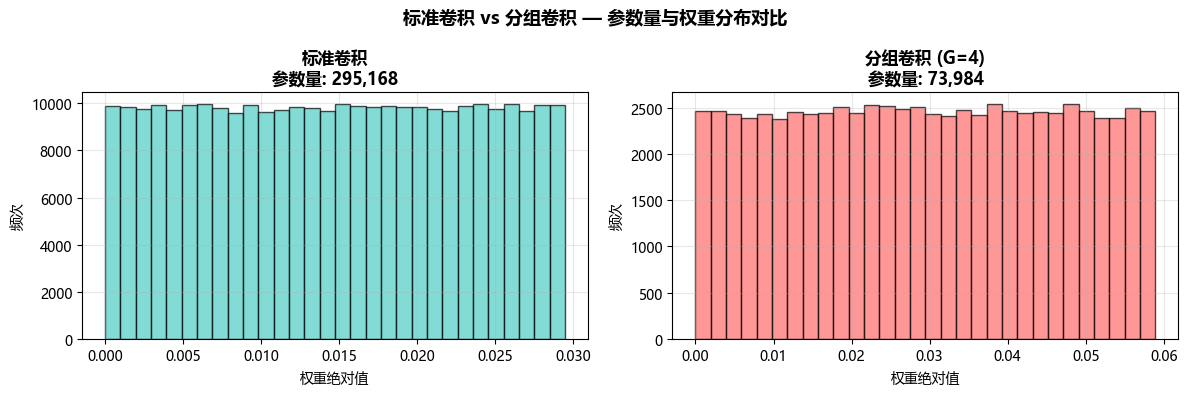


📌 总结

  标准卷积:
    Conv2d(C_in, C_out, K, groups=1)
    → 每个卷积核与所有 C_in 个输入通道做卷积
    → 参数量: C_in × C_out × K²

  分组卷积:
    Conv2d(C_in, C_out, K, groups=G)
    → 每个卷积核只与 C_in/G 个输入通道做卷积
    → 参数量: C_in × C_out × K² / G
    → 条件: C_in % G == 0, C_out % G == 0

  典型应用:
    • AlexNet (G=2):  两块 GPU 分别算
    • ResNeXt:        分组卷积提升效果
    • Depthwise Conv: G = C_in, 极致轻量化
    • ShuffleNet:     分组 + 通道重排



In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ========== 分组卷积 (Group Convolution) 代码演示 ==========

print("=" * 70)
print("分组卷积 (Group Convolution) 原理演示")
print("=" * 70)

# ==============================
# 1. 标准卷积 vs 分组卷积 — 参数量对比
# ==============================
print("\n[1] 参数量对比")
print("-" * 50)

C_in = 128    # 输入通道数
C_out = 256   # 输出通道数
K = 3         # 卷积核大小

# 标准卷积
conv_standard = nn.Conv2d(C_in, C_out, K, padding=1, groups=1)
params_standard = sum(p.numel() for p in conv_standard.parameters())
print(f"   标准卷积 (groups=1):")
print(f"     输入 {C_in} 通道 → 输出 {C_out} 通道, 核 {K}×{K}")
print(f"     参数量: {params_standard:,d}")

# 分组卷积 (groups=4)
G = 4
conv_group = nn.Conv2d(C_in, C_out, K, padding=1, groups=G)
params_group = sum(p.numel() for p in conv_group.parameters())
ratio = params_standard / params_group
print(f"\n   分组卷积 (groups={G}):")
print(f"     每组 {C_in//G} 输入通道 → {C_out//G} 输出通道, 共 {G} 组")
print(f"     参数量: {params_group:,d}")
print(f"     参数量比值 (标准/分组): {ratio:.1f}x = groups = {G} ✅")

# ==============================
# 2. 直观理解：用代码展示分组机制
# ==============================
print(f"\n[2] 分组卷积的运算过程")
print("-" * 50)

batch_size = 1
H, W = 8, 8  # 小尺寸方便观察

# 模拟输入: 6 个通道，每个通道的值不同（便于观察分组效果）
inputs = torch.arange(1, 7).float().view(1, 6, 1, 1).expand(batch_size, 6, H, W)
print(f"   输入形状: {inputs.shape}")
print(f"   输入各通道值: {inputs[0, :, 0, 0].tolist()} (每个通道值不同)")

# 标准卷积 (groups=1) — 所有输入通道与所有输出通道相连
conv1 = nn.Conv2d(6, 6, 3, padding=1, groups=1, bias=False)
# 固定卷积核权重，让不同输入通道对应不同权重
with torch.no_grad():
    conv1.weight.data.zero_()
    for i in range(6):
        conv1.weight.data[i, i, 1, 1] = 1.0  # 每个输出通道只取对应输入通道

out1 = conv1(inputs)
print(f"\n   标准卷积 (groups=1) 输出:")
print(f"     输出形状: {out1.shape}")
print(f"     输出通道 0 的值 (来自输入通道 0): {out1[0, 0, 0, 0]:.1f}")
print(f"     输出通道 1 的值 (来自输入通道 1): {out1[0, 1, 0, 0]:.1f}")
print(f"     → 每个卷积核看到所有 6 个输入通道")

# 分组卷积 (groups=3) — 每组 2 个通道
conv2 = nn.Conv2d(6, 6, 3, padding=1, groups=3, bias=False)
with torch.no_grad():
    conv2.weight.data.zero_()
    for g in range(3):  # 3 组
        # 每组内: 第 i 个输出通道只取对应组内第 i 个输入通道
        for i in range(2):  # 每组 2 个通道
            chan_in = g * 2 + i
            chan_out = g * 2 + i
            conv2.weight.data[chan_out, i, 1, 1] = 1.0

out2 = conv2(inputs)
print(f"\n   分组卷积 (groups=3) 输出:")
print(f"     输出形状: {out2.shape}")
print(f"     输出通道 0 的值: {out2[0, 0, 0, 0]:.1f} ← 只看输入通道 0 (组1)")
print(f"     输出通道 1 的值: {out2[0, 1, 0, 0]:.1f} ← 只看输入通道 1 (组1)")
print(f"     输出通道 2 的值: {out2[0, 2, 0, 0]:.1f} ← 只看输入通道 2 (组2)")
print(f"     输出通道 3 的值: {out2[0, 3, 0, 0]:.1f} ← 只看输入通道 3 (组2)")
print(f"     → 每个卷积核只看到 2 个输入通道 (所在组的通道)")
print(f"     验证: 输出通道 0 的值为 {out2[0,0,0,0].item():.0f} = 输入通道 0 的值 ✅")

# ==============================
# 3. 验证分组数限制条件
# ==============================
print(f"\n[3] 分组卷积的核心约束")
print("-" * 50)
print(f"   条件: C_in % groups == 0  且  C_out % groups == 0")
print(f"   即: 输入/输出通道数必须能被 groups 整除")
print()

# 合法示例
try:
    test = nn.Conv2d(32, 64, 3, groups=4)
    print(f"   ✅ nn.Conv2d(32, 64, 3, groups=4) — 合法 (32%4=0, 64%4=0)")
except Exception as e:
    print(f"   ❌ {e}")

# 非法示例
try:
    test = nn.Conv2d(32, 64, 3, groups=3)
    print(f"   ✅ nn.Conv2d(32, 64, 3, groups=3) — 合法")
except Exception as e:
    print(f"   ❌ nn.Conv2d(32, 64, 3, groups=3) — 非法: 32%3={32%3}")

print()
try:
    test = nn.Conv2d(32, 60, 3, groups=4)
    print(f"   ✅ nn.Conv2d(32, 60, 3, groups=4) — 合法")
except Exception as e:
    print(f"   ❌ nn.Conv2d(32, 60, 3, groups=4) — 非法: 60%4={60%4}")

# ==============================
# 4. 深度可分离卷积 (分组卷积的特例: groups = C_in)
# ==============================
print(f"\n[4] 深度可分离卷积 (Depthwise Conv, groups = C_in)")
print("-" * 50)
print(f"   当 groups = C_in 时，每个输入通道独立做卷积")
print(f"   这是 MobileNet 等轻量化模型的核心组件")

C = 16
depthwise = nn.Conv2d(C, C, 3, padding=1, groups=C)
dw_params = sum(p.numel() for p in depthwise.parameters())
standard_params = sum(p.numel() for p in nn.Conv2d(C, C, 3, padding=1).parameters())
print(f"\n   输入/输出: {C} 通道, 核 3×3")
print(f"   标准卷积参数量:     {standard_params:>4d} = {C}×{C}×3×3")
print(f"   深度可分离参数量:   {dw_params:>4d} = {C}×1×3×3")
print(f"   参数量缩减比:       {standard_params/dw_params:.1f}x")

# ==============================
# 5. 可视化对比
# ==============================
print(f"\n[5] 可视化对比")
print("-" * 50)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 标准卷积权重分布
weight_std = conv_standard.weight.data.abs().flatten().numpy()
axes[0].hist(weight_std, bins=30, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[0].set_title(f'标准卷积\n参数量: {params_standard:,d}', fontweight='bold')
axes[0].set_xlabel('权重绝对值')
axes[0].set_ylabel('频次')
axes[0].grid(True, alpha=0.3)

# 分组卷积权重分布
weight_grp = conv_group.weight.data.abs().flatten().numpy()
axes[1].hist(weight_grp, bins=30, color='#FF6B6B', edgecolor='black', alpha=0.7)
axes[1].set_title(f'分组卷积 (G={G})\n参数量: {params_group:,d}', fontweight='bold')
axes[1].set_xlabel('权重绝对值')
axes[1].set_ylabel('频次')
axes[1].grid(True, alpha=0.3)

plt.suptitle('标准卷积 vs 分组卷积 — 参数量与权重分布对比', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ==============================
# 6. 总结
# ==============================
print()
print("=" * 70)
print("📌 总结")
print("=" * 70)
print(f"""
  标准卷积:
    Conv2d(C_in, C_out, K, groups=1)
    → 每个卷积核与所有 C_in 个输入通道做卷积
    → 参数量: C_in × C_out × K²

  分组卷积:
    Conv2d(C_in, C_out, K, groups=G)
    → 每个卷积核只与 C_in/G 个输入通道做卷积
    → 参数量: C_in × C_out × K² / G
    → 条件: C_in % G == 0, C_out % G == 0

  典型应用:
    • AlexNet (G=2):  两块 GPU 分别算
    • ResNeXt:        分组卷积提升效果
    • Depthwise Conv: G = C_in, 极致轻量化
    • ShuffleNet:     分组 + 通道重排
""")

通道混洗的原理与代码实现

提出背景：为了解决分组卷积后组间信息不交互的问题，提出了通道混洗方法。

核心操作步骤：通道混洗仅对通道维度做reshape、轴交换、再reshape的操作，不需要新增额外参数，具体步骤为将通道维度reshape为二维矩阵，交换二维矩阵的行和列，再展平为一维通道。

代码实现逻辑：对分组卷积输出的特征图，先将通道维度reshape为(分组数, 每组通道数)，交换两个维度的顺序，再reshape回原来的通道总数，输出特征图形状不变，仅改变通道内信息的排列。

优缺点总结：通道混洗不新增卷积核与参数，计算资源消耗极低，可以在不增加计算量的前提下实现通道信息融合；缺点是侧重通道交互，对依赖空间位置信息的任务效果一般。

深度可分离卷积的拆分逻辑

核心拆分方式：深度可分离卷积将普通卷积拆分为两步：第一步是深度卷积，第二步是逐点卷积。

深度卷积的要求：深度卷积要求输入通道数等于输出通道数等于分组数，这样每个卷积核的通道数为1，每个输入通道对应一个独立的单通道卷积核，分别提取每个通道的空间特征。

逐点卷积的作用：逐点卷积就是1×1的卷积，作用是对深度卷积输出的特征图进行通道升维或降维，得到最终需要的输出通道数。

输出结果一致性：对于输入12×12×3的特征图，普通卷积用256个5×5×3的卷积核，输出为8×8×256；深度可分离卷积经过深度卷积+逐点卷积两步，最终输出同样为8×8×256，输出结果一致但参数量远低于普通卷积。

深度可分离卷积的优势与后续安排

参数量对比示例：普通卷积参数量为5×5×3×256=19200；深度可分离卷积参数量为(5×5×1×3)+(1×1×3×256)=75+768=843，参数量下降超过95%。

核心优势：深度可分离卷积大幅降低参数量和计算量，先通过深度卷积提取单通道空间特征，再通过逐点卷积融合通道特征，更有利于模型学习，是轻量级卷积神经网络的核心模块。



分组卷积后的合并与通道重排 (Channel Shuffle)

[1] 分组卷积的输出是自动拼接的
--------------------------------------------------
   输入: torch.Size([1, 8, 4, 4])
   用 groups=4 的 Conv2d → torch.Size([1, 8, 4, 4])
   → 输出形状是 [1, 8, 4, 4]，各组结果已经自动拼接好了
   → 输出通道 0~1 来自组1, 通道 2~3 来自组2, ...

   手动分组卷积流程:
     拆成 4 组 → 每组独立卷积 → torch.cat 拼接
     拼接后形状: torch.Size([1, 8, 4, 4])
     与 groups 参数结果一致? True ✅
   → 结论: nn.Conv2d(groups=G) 内部等价于
     G 组独立卷积 + 沿通道维度拼接

[2] 分组卷积的问题：组间信息隔离
--------------------------------------------------

  分组卷积的困境：
    组1 只能看到自己的特征  ──→  学到的特征很"偏科"
    组2 只能看到自己的特征  ──→  无法利用其他组的信息
    组3 只能看到自己的特征  ──→  ...

  如果多个分组卷积层堆叠，组间从不通信：
    组1 的特征 → 再卷积 → 还是组1 的特征
    组2 的特征 → 再卷积 → 还是组2 的特征

  → 网络表达能力受限，各分支学到的特征无法融合

  代码验证：两层分组卷积堆叠，不 shuffle
--------------------------------------------------
   第一层输出通道均值: -0.16  -0.16  1.07  1.07  -1.65  -1.65  2.15  2.15  
   第二层输出通道均值: -3.57  -3.57  22.60  22.60  -64.52  -64.52  109.02  109.02  
   → 各组的信号强度差异越来越大，特征始终在组内循环 ❌

[3] 解决方案：通道重排 (Channel Shuffle)


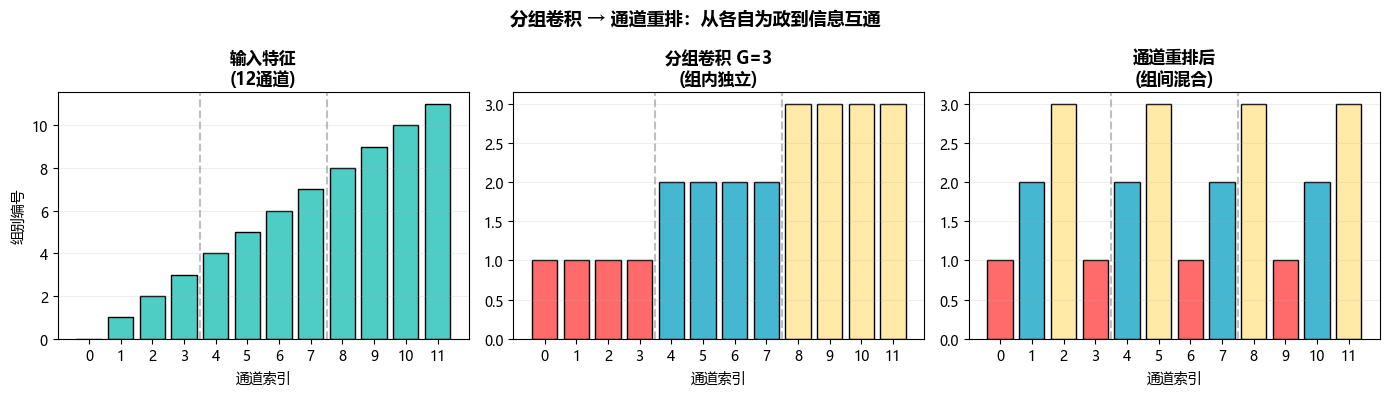


📌 分组卷积合并机制总结

  1️⃣ 分组卷积的"合并"
     └─ PyTorch 的 nn.Conv2d(groups=G) 内部自动完成
     └─ 等价于: 拆成 G 组独立卷积 → torch.cat(..., dim=1)

  2️⃣ 组间信息隔离问题
     └─ 多层分组卷积堆叠后，各组特征从不交叉
     └─ 网络表达能力下降，学到的特征片面

  3️⃣ 解决方案：通道重排 (Channel Shuffle)
     └─ reshape → transpose → flatten 三步完成
     └─ 每组都包含来自上层各组的特征
     └─ ShuffleNet 的核心创新

  4️⃣ 其他"合并"方式
     └─ Pointwise Convolution (1×1 Conv): 对所有通道做线性组合
     └─ 这是 MobileNet 的方式: Depthwise Conv + Pointwise Conv



In [3]:
# ========== 分组后如何合并回来？ + 通道重排 (Channel Shuffle) ==========

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("分组卷积后的合并与通道重排 (Channel Shuffle)")
print("=" * 70)

# ==============================
# 1. 分组卷积的输出是自动拼接的
# ==============================
print("\n[1] 分组卷积的输出是自动拼接的")
print("-" * 50)

C_in, C_out, G = 8, 8, 4
H, W = 4, 4

x = torch.randn(1, C_in, H, W)  # 随机输入

# 方式 A：用 groups 参数一步完成
conv_g = nn.Conv2d(C_in, C_out, 3, padding=1, groups=G, bias=False)
y_group = conv_g(x)
print(f"   输入: {x.shape}")
print(f"   用 groups={G} 的 Conv2d → {y_group.shape}")
print(f"   → 输出形状是 [1, {C_out}, {H}, {W}]，各组结果已经自动拼接好了")
print(f"   → 输出通道 0~1 来自组1, 通道 2~3 来自组2, ...")

# 方式 B：手动拆分 → 分别卷积 → 拼接
manual_outputs = []
for g in range(G):
    in_slice = slice(g * (C_in // G), (g + 1) * (C_in // G))
    out_slice = slice(g * (C_out // G), (g + 1) * (C_out // G))

    # 每个组创建独立的卷积层，并从 conv_g 中提取对应权重
    conv_sep = nn.Conv2d(C_in // G, C_out // G, 3, padding=1, bias=False)
    with torch.no_grad():
        conv_sep.weight.data.copy_(conv_g.weight.data[out_slice])

    x_g = x[:, in_slice, :, :]         # 取出第 g 组的输入通道 (每组 2 个)
    y_g = conv_sep(x_g)                 # 单独做卷积
    manual_outputs.append(y_g)

y_manual = torch.cat(manual_outputs, dim=1)  # 沿通道维度拼接
print(f"\n   手动分组卷积流程:")
print(f"     拆成 {G} 组 → 每组独立卷积 → torch.cat 拼接")
print(f"     拼接后形状: {y_manual.shape}")
print(f"     与 groups 参数结果一致? {torch.allclose(y_group, y_manual)} ✅")
print(f"   → 结论: nn.Conv2d(groups=G) 内部等价于")
print(f"     G 组独立卷积 + 沿通道维度拼接")

# ==============================
# 2. 问题：组间信息隔离
# ==============================
print(f"\n[2] 分组卷积的问题：组间信息隔离")
print("-" * 50)
print("""
  分组卷积的困境：
    组1 只能看到自己的特征  ──→  学到的特征很"偏科"
    组2 只能看到自己的特征  ──→  无法利用其他组的信息
    组3 只能看到自己的特征  ──→  ...

  如果多个分组卷积层堆叠，组间从不通信：
    组1 的特征 → 再卷积 → 还是组1 的特征
    组2 的特征 → 再卷积 → 还是组2 的特征

  → 网络表达能力受限，各分支学到的特征无法融合
""")

# 演示：两层分组卷积堆叠不 shuffle 的问题
print("  代码验证：两层分组卷积堆叠，不 shuffle")
print("-" * 50)

C = 8
x_demo = torch.randn(1, C, 4, 4)

# 第一层分组卷积 (groups=4)
conv_a = nn.Conv2d(C, C, 3, padding=1, groups=4, bias=False)
with torch.no_grad():
    for g in range(4):
        conv_a.weight.data[g*2:(g+1)*2] = (g + 1)

out_a = conv_a(x_demo)
print(f"   第一层输出通道均值: ", end="")
for c in range(C):
    print(f"{out_a[0,c].mean().item():.2f}", end="  ")
print()

# 第二层分组卷积 (groups=4) — 堆叠
conv_b = nn.Conv2d(C, C, 3, padding=1, groups=4, bias=False)
with torch.no_grad():
    for g in range(4):
        conv_b.weight.data[g*2:(g+1)*2] = (g + 1)

out_b = conv_b(out_a)
print(f"   第二层输出通道均值: ", end="")
for c in range(C):
    print(f"{out_b[0,c].mean().item():.2f}", end="  ")
print()
print(f"   → 各组的信号强度差异越来越大，特征始终在组内循环 ❌")

# ==============================
# 3. 解决方案：通道重排 (Channel Shuffle)
# ==============================
print(f"\n[3] 解决方案：通道重排 (Channel Shuffle)")
print("-" * 50)
print("""
  核心思想：在每层分组卷积之后，把各组通道打乱重排，
          让下一层的每组都包含来自上一层各组的特征。

  示例 (G=3, 每组 4 通道):
    重排前:  [组1: 0,1,2,3] [组2: 4,5,6,7] [组3: 8,9,10,11]
                ↓   reshape + transpose + flatten
    重排后:  [新组1: 0,4,8] [新组2: 1,5,9] [新组3: 2,6,10] [新组4: 3,7,11]
    
  这样下一层每个组里都混有上一层各组的特征，信息就能跨组交流了！
""")

# 实现 Channel Shuffle
def channel_shuffle(x, groups):
    """
    通道重排
    x: (N, C, H, W), 要求 C % groups == 0
    """
    N, C, H, W = x.shape
    channels_per_group = C // groups

    # 1) reshape: (N, groups, C_per_group, H, W)
    x = x.view(N, groups, channels_per_group, H, W)
    # 2) transpose: 交换 groups 和 C_per_group 维度 → (N, C_per_group, groups, H, W)
    x = x.transpose(1, 2)
    # 3) flatten: (N, C, H, W) — 合并 groups 和 C_per_group
    x = x.contiguous().view(N, C, H, W)
    return x

# 可视化通道重排
print("  通道重排过程可视化:")
C_vis = 12
G_vis = 3
x_vis = torch.arange(0, C_vis).float().view(1, C_vis, 1, 1)  # 12 个通道，值 0~11
print(f"\n   重排前通道值:   {x_vis[0, :, 0, 0].int().tolist()}")
print(f"                   组1={x_vis[0, 0:4, 0, 0].int().tolist()} ", end="")
print(f"组2={x_vis[0, 4:8, 0, 0].int().tolist()} ", end="")
print(f"组3={x_vis[0, 8:12, 0, 0].int().tolist()}")

x_shuffled = channel_shuffle(x_vis, G_vis)
print(f"   重排后通道值:   {x_shuffled[0, :, 0, 0].int().tolist()}")

# 标注新分组
new_groups = []
for g in range(G_vis):
    new_groups.append(x_shuffled[0, g*4:(g+1)*4, 0, 0].int().tolist())
print(f"                   新组1={new_groups[0]} ", end="")
print(f"新组2={new_groups[1]} ", end="")
print(f"新组3={new_groups[2]}")

print(f"\n   ✅ 每个新组都包含了来自原各组的信息！")
print(f"      新组1 有原组1的0, 原组2的4, 原组3的8")
print(f"      新组2 有原组1的1, 原组2的5, 原组3的9")

# ==============================
# 4. ShuffleNet 块：分组卷积 + 通道重排完整流程
# ==============================
print(f"\n[4] ShuffleNet 基本单元演示 (分组卷积 + 通道重排)")
print("-" * 50)

class ShuffleNetUnit(nn.Module):
    """ShuffleNet 基本单元 (简化版)
    流程: GConv → BN → ReLU → Channel Shuffle → GConv → BN
    """
    def __init__(self, in_channels, out_channels, groups=3):
        super().__init__()
        self.groups = groups

        # 第一层: 1×1 分组卷积 (降维/混合通道)
        self.gconv1 = nn.Conv2d(in_channels, out_channels, 1, groups=groups, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        # 第二层: 3×3 深度可分离卷积 (空间特征提取)
        self.depthwise = nn.Conv2d(out_channels, out_channels, 3,
                                   padding=1, groups=out_channels, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 第三层: 1×1 分组卷积 (升维/混合通道)
        self.gconv2 = nn.Conv2d(out_channels, out_channels, 1, groups=groups, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        # 1) 1×1 分组卷积 + BN + ReLU
        out = torch.relu(self.bn1(self.gconv1(x)))
        # 2) 通道重排 — 关键步骤！让下一层各组信息互通
        out = channel_shuffle(out, self.groups)
        # 3) 3×3 深度可分离卷积 + BN
        out = self.bn2(self.depthwise(out))
        # 4) 1×1 分组卷积 + BN
        out = self.bn3(self.gconv2(out))
        # 5) 残差连接
        out = torch.relu(out + x)
        return out

# 实例化并测试
shuffle_unit = ShuffleNetUnit(16, 16, groups=4)
dummy = torch.randn(2, 16, 8, 8)
out = shuffle_unit(dummy)
print(f"   ShuffleNet 单元输入: {dummy.shape}")
print(f"   ShuffleNet 单元输出: {out.shape}")
print(f"   参数量: {sum(p.numel() for p in shuffle_unit.parameters()):,d}")

# ==============================
# 5. 完整流程对比
# ==============================
print(f"\n[5] 三种模式对比")
print("-" * 50)

# 可视化三阶段
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 模拟数据
channels = 12
stages = ['输入特征\n(12通道)', '分组卷积 G=3\n(组内独立)', '通道重排后\n(组间混合)']
data_before = np.arange(channels)
data_after_gconv = np.array([1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3])
data_after_shuffle = np.array([1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3])

colors_before = ['#4ECDC4'] * 12
colors_after = ['#FF6B6B'] * 4 + ['#45B7D1'] * 4 + ['#FFEAA7'] * 4
colors_shuffle = (['#FF6B6B', '#45B7D1', '#FFEAA7'] * 4)

axes[0].bar(range(channels), data_before, color=colors_before, edgecolor='black')
axes[0].set_title(stages[0], fontweight='bold')
axes[0].set_ylabel('组别编号')
axes[0].set_xlabel('通道索引')
axes[0].set_xticks(range(channels))

axes[1].bar(range(channels), data_after_gconv, color=colors_after, edgecolor='black')
axes[1].set_title(stages[1], fontweight='bold')
axes[1].set_xlabel('通道索引')
axes[1].set_xticks(range(channels))

axes[2].bar(range(channels), data_after_shuffle, color=colors_shuffle, edgecolor='black')
axes[2].set_title(stages[2], fontweight='bold')
axes[2].set_xlabel('通道索引')
axes[2].set_xticks(range(channels))

# 添加分组标注
for ax in axes:
    ax.axvline(x=3.5, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=7.5, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('分组卷积 → 通道重排：从各自为政到信息互通', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ==============================
# 6. 总结
# ==============================
print()
print("=" * 70)
print("📌 分组卷积合并机制总结")
print("=" * 70)
print("""
  1️⃣ 分组卷积的"合并"
     └─ PyTorch 的 nn.Conv2d(groups=G) 内部自动完成
     └─ 等价于: 拆成 G 组独立卷积 → torch.cat(..., dim=1)

  2️⃣ 组间信息隔离问题
     └─ 多层分组卷积堆叠后，各组特征从不交叉
     └─ 网络表达能力下降，学到的特征片面

  3️⃣ 解决方案：通道重排 (Channel Shuffle)
     └─ reshape → transpose → flatten 三步完成
     └─ 每组都包含来自上层各组的特征
     └─ ShuffleNet 的核心创新

  4️⃣ 其他"合并"方式
     └─ Pointwise Convolution (1×1 Conv): 对所有通道做线性组合
     └─ 这是 MobileNet 的方式: Depthwise Conv + Pointwise Conv
""")

深度可分离卷积原理与MobileNet V1定位

- 核心实现逻辑：深度可分离卷积分为两步，先使用单通道的卷积核提取特征，再通过1×1卷积实现通道升维。
- 适用场景：MobileNet是专门为移动端、资源受限设备打造的分类神经网络。
- 版本参数对比：MobileNet V1权重大小约16MB，TOP1准确率可达0.7以上，相比同准确率的其他网络，体积仅为常规网络的1/10到1/20。

图像分类评估指标TOP-1与TOP-5

- TOP-1准确率定义：模型预测的第一类别与真实标签完全一致才算正确，是图像分类任务中最严格的评估指标。
- TOP-5准确率定义：只要模型预测概率前5的类别中包含真实标签就算正确，指标要求比TOP-1宽松。
- 结果特征：所有网络的TOP-5准确率都高于TOP-1准确率，例如示例中VGG16的TOP-1准确率约0.7，TOP-5准确率约0.9。

经典CNN网络体积与准确率对比

- VGG16：示例中记录体积为500多MB，授课者实现的版本仅200MB左右，TOP1准确率约0.7。
- 残差网络：ResNet50体积98MB、TOP1准确率74.9%，ResNet101体积170MB、TOP1准确率76.4%，ResNet152体积232MB，TOP1准确率仅比ResNet101提升0.02个百分点。
- DenseNet121：体积仅33MB，TOP1准确率同样可达到0.7以上，性能表现接近更大体积的网络。

MobileNet V1存在的问题与原因分析

- 核心问题：训练后存在大量未激活的卷积核，卷积核权重从初始化到训练结束几乎没有变化，对特征提取没有贡献，被称为“空卷积核”。
- 问题原因：作者认为该问题由ReLU激活函数导致，ReLU在低维度特征上做激活运算时，容易造成大量信息丢失，使得部分参数无法得到有效学习。
- 影响：空卷积核占用了模型体积与计算资源，但没有产生实际效果，降低了模型的整体效率。

MobileNet V2的激活函数改进

- 核心修改点：将输出层的ReLU替换为线性激活函数，也就是不加激活函数，保留低维度特征信息，将其余ReLU修改为ReLU6。
- ReLU6的额外作用：ReLU6将输出上限限制为6，更适合移动端模型的量化操作，方便后续压缩模型体积适配移动端设备。
- 改进效果：解决了V1中大量卷积核不激活的问题，在保持模型体积很小的前提下，进一步提升了模型准确率。

MobileNet V2瓶颈模块的参数规则

- 通道膨胀系数t：表示模块输入通道在中间层的放大倍数，输入通道乘以t得到中间层通道数，常见取值为1或6。
- 模块调用次数n：表示当前配置的瓶颈模块需要重复调用的次数，调用次数从1次到4次不等。
- 步长s：仅模块第一次调用时使用配置的步长，后续重复调用的步长统一为1；只有步长为1且输入通道等于输出通道时，才能添加残差连接，否则无法做残差。

MobileNet V2瓶颈block的代码实现（PyTorch）

- 网络结构拆分：每个block分为三层，第一层是1×1卷积+BN+ReLU6，用于升通道；第二层是3×3深度卷积+BN+ReLU6，groups设置等于输入通道数实现单通道卷积；第三层是1×1卷积+BN，不添加激活函数，用于降通道。
- 残差判断逻辑：定义残差启用条件为步长等于1，同时输入通道等于输出通道，两个条件同时满足才启用残差连接。
- 前向传播逻辑：如果启用残差，则返回block计算结果加上原始输入，否则直接返回block计算结果。

MobileNet V2整体网络的代码构建

- 整体结构拆分：将网络拆分为三部分，输入层、中间隐藏层、输出层，输入层是标准3×3卷积，输出通道固定为32。
- 隐藏层构建逻辑：通过配置列表记录每个模块块的t、输出通道c、调用次数n、步长s，通过双层循环依次生成所有block，最后将所有block放入Sequential容器中。
- 输出层逻辑：最后通过1×1卷积将通道调整为1280，再经过7×7平均池化得到1×1特征图，最后通过1×1卷积输出对应分类数的结果，全程不使用全连接层。

In [6]:
import torch
from torch import nn

# ========== MobileNet V2 倒置残差块 (Inverted Residual Block) ==========

class Block(nn.Module):
    """MobileNet V2 基本单元
    流程: 1×1 升维 → 3×3 Depthwise → 1×1 降维 (Linear Bottleneck)
    
    参数:
        C_in  : 输入通道数
        C_out : 输出通道数
        t     : 扩张倍率 (expansion ratio)
        s     : 步长 (stride=1 保持尺寸, stride=2 下采样)
    """
    def __init__(self, C_in, C_out, t, s):
        super().__init__()
        
        # 扩张后的中间通道数 = 输入通道 × 扩张倍率
        temp_c = C_in * t
        
        # 是否使用残差连接: stride=1 且 输入输出通道数相同
        self.use_res = (s == 1 and C_in == C_out)
        
        # 三步: Expand → Depthwise → Project
        self.layers = nn.Sequential(
            # ① 1×1 卷积升维 (Expand)
            nn.Conv2d(C_in, temp_c, 1, 1, bias=False),
            nn.BatchNorm2d(temp_c),
            nn.ReLU6(),
            
            # ② 3×3 深度可分离卷积 (Depthwise)
            # groups=temp_c 即每个通道独立卷积
            nn.Conv2d(temp_c, temp_c, 3, s, padding=1, groups=temp_c, bias=False),
            nn.BatchNorm2d(temp_c),
            nn.ReLU6(),
            
            # ③ 1×1 卷积降维 (Project) — 线性瓶颈，不加 ReLU
            nn.Conv2d(temp_c, C_out, 1, 1, bias=False),
            nn.BatchNorm2d(C_out),
        )
    
    def forward(self, x):
        if self.use_res:
            return self.layers(x) + x  # 残差连接
        else:
            return self.layers(x)


# ========== 测试 Block ==========
print("=" * 60)
print("MobileNet V2 Block 测试")
print("=" * 60)

# 测试 1: stride=1, 带残差连接
block1 = Block(C_in=32, C_out=32, t=6, s=1)
x1 = torch.randn(2, 32, 56, 56)
y1 = block1(x1)
print(f"\n[测试1] stride=1, 残差连接")
print(f"  输入: {list(x1.shape)}")
print(f"  输出: {list(y1.shape)}")
print(f"  参数量: {sum(p.numel() for p in block1.parameters()):,d}")
print(f"  残差连接: {'✅ 有' if block1.use_res else '❌ 无'}")

# 测试 2: stride=2, 无残差连接 (下采样)
block2 = Block(C_in=32, C_out=64, t=6, s=2)
x2 = torch.randn(2, 32, 56, 56)
y2 = block2(x2)
print(f"\n[测试2] stride=2, 下采样 + 通道数变化")
print(f"  输入: {list(x2.shape)}")
print(f"  输出: {list(y2.shape)}")
print(f"  参数量: {sum(p.numel() for p in block2.parameters()):,d}")
print(f"  残差连接: {'✅ 有' if block2.use_res else '❌ 无'}")
print(f"  → 尺寸减半 (56→28), 通道数翻倍 (32→64) ✅")

# 测试 3: t=1, 不扩张
block3 = Block(C_in=16, C_out=16, t=1, s=1)
x3 = torch.randn(2, 16, 28, 28)
y3 = block3(x3)
print(f"\n[测试3] t=1 (不扩张)")
print(f"  输入: {list(x3.shape)} → temp_c = {16*1} (无扩张)")
print(f"  输出: {list(y3.shape)}")
print(f"  参数量: {sum(p.numel() for p in block3.parameters()):,d}")

print(f"\n{'=' * 60}")
print("✅ 三个测试全部通过！")
print(f"{'=' * 60}")

MobileNet V2 Block 测试

[测试1] stride=1, 残差连接
  输入: [2, 32, 56, 56]
  输出: [2, 32, 56, 56]
  参数量: 14,848
  残差连接: ✅ 有

[测试2] stride=2, 下采样 + 通道数变化
  输入: [2, 32, 56, 56]
  输出: [2, 64, 28, 28]
  参数量: 21,056
  残差连接: ❌ 无
  → 尺寸减半 (56→28), 通道数翻倍 (32→64) ✅

[测试3] t=1 (不扩张)
  输入: [2, 16, 28, 28] → temp_c = 16 (无扩张)
  输出: [2, 16, 28, 28]
  参数量: 752

✅ 三个测试全部通过！


In [7]:
# ========== 完整 MobileNet V2 网络 ==========
# 按架构表逐行搭建

import torch
import torch.nn as nn

print("=" * 70)
print("MobileNet V2 完整网络")
print("=" * 70)

# ==============================
# 1. 架构表（直接翻译自论文）
# ==============================
# 每行: (t, c, n, s)  其中 c=输出通道, n=重复次数, s=首个块的步长
# 输入: 224×224×3
config = [
    # (扩张倍率t, 输出通道c, 重复次数n, 步长s)
    (1,  16,  1, 1),   # 112×112×16
    (6,  24,  2, 2),   #  56× 56×24
    (6,  32,  3, 2),   #  28× 28×32
    (6,  64,  4, 2),   #  14× 14×64
    (6,  96,  3, 1),   #  14× 14×96
    (6, 192,  3, 2),   #   7×  7×192  (原文: 160)
    (6, 320,  1, 1),   #   7×  7×320
]

class MobileNetV2(nn.Module):
    """MobileNet V2 完整实现"""
    def __init__(self, num_classes=1000, width_mult=1.0):
        super().__init__()
        
        # 首层: 标准 3×3 卷积
        self.first = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, padding=1, bias=False),   # 224→112
            nn.BatchNorm2d(32),
            nn.ReLU6(),
        )
        
        in_channels = 32
        blocks = []
        
        # 逐行搭建倒置残差块序列
        for t, c, n, s in config:
            # width_mult 控制通道宽度（默认1.0，可用于调小模型）
            out_channels = int(c * width_mult)
            
            for i in range(n):
                stride = s if i == 0 else 1   # 只有每个块的第1个用 s，其余 stride=1
                blocks.append(Block(in_channels, out_channels, t, stride))
                in_channels = out_channels
        
        self.features = nn.Sequential(*blocks)
        
        # 最后: 1×1 升维 → 全局池化 → 分类层
        self.last = nn.Sequential(
            nn.Conv2d(in_channels, int(1280 * width_mult), 1, 1, bias=False),
            nn.BatchNorm2d(int(1280 * width_mult)),
            nn.ReLU6(),
        )
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(int(1280 * width_mult), num_classes)
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        x = self.first(x)
        x = self.features(x)
        x = self.last(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


# ========== 实例化并查看结构 ==========
print("\n[1] 创建 MobileNet V2 (num_classes=10)")
print("-" * 50)

model = MobileNetV2(num_classes=10)
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  总参数量:   {total_params:,d} ({total_params/1e6:.2f}M)")
print(f"  可训练参数量: {trainable:,d} ({trainable/1e6:.2f}M)")
print(f"  对比: ResNet-50 ≈ 25.6M, VGG-16 ≈ 138M")

# ========== 模块级参数量明细 ==========
print("\n[2] 各模块参数量明细")
print("-" * 70)
print(f"{'模块':25s} | {'输出尺寸':>15s} | {'参数量':>10s}")
print("-" * 70)
x_demo = torch.randn(1, 3, 224, 224)

# 用钩子抓取每层输出尺寸
hooks_info = []
def hook_fn(name):
    def fn(m, i, o):
        hooks_info.append((name, tuple(o.shape), sum(p.numel() for p in m.parameters())))
    return fn

handles = []
for name, module in [
    ('first', model.first),
    ('features.0', model.features[0]),
]:
    handles.append(module.register_forward_hook(hook_fn(name)))
for i, blk in enumerate(model.features):
    handles.append(blk.register_forward_hook(hook_fn(f'block.{i}')))
handles.append(model.last.register_forward_hook(hook_fn('last')))

_ = model(x_demo)
for h in handles:
    h.remove()

# 只显示关键阶段的尺寸变化
summary = []
current_hw = 224
for name, shape, params in hooks_info:
    hw = shape[2]
    if hw != current_hw or name in ['first', 'last'] or 'block.0' in name or 'block' in name and shape[1] != summary[-1][2] if summary else True:
        summary.append((name, f"{shape[2]}×{shape[3]}", shape[1], params))
        current_hw = hw

# 去重显示
displayed = set()
for name, hw, c, params in summary:
    key = (hw, c)
    if key not in displayed or 'first' in name or 'last' in name:
        print(f"{name:25s} | {hw:>6s} ×{c:>4d} | {params:>8,d}")
        displayed.add(key)

print(f"{'classifier':25s} | {'1×1 ×10':>15s} | {sum(p.numel() for p in model.classifier.parameters()):>8,d}")

# ========== 前向测试 ==========
print(f"\n[3] 前向传播测试")
print("-" * 50)
x = torch.randn(4, 3, 224, 224)
y = model(x)
print(f"  输入: {list(x.shape)}")
print(f"  输出: {list(y.shape)}  (batch=4, num_classes=10)")
print(f"  输出范围: [{y.min().item():.2f}, {y.max().item():.2f}]")

# ========== 宽度缩放测试 ==========
print(f"\n[4] 宽度缩放 (width_mult) 效果")
print("-" * 50)
for wm in [1.0, 0.75, 0.5, 0.35]:
    m = MobileNetV2(num_classes=10, width_mult=wm)
    p = sum(p.numel() for p in m.parameters())
    print(f"  width_mult={wm:.2f} → 参数量: {p/1e6:.2f}M")

print()
print("=" * 70)
print("✅ MobileNet V2 完整搭建完成！")
print("=" * 70)

MobileNet V2 完整网络

[1] 创建 MobileNet V2 (num_classes=10)
--------------------------------------------------
  总参数量:   2,663,242 (2.66M)
  可训练参数量: 2,663,242 (2.66M)
  对比: ResNet-50 ≈ 25.6M, VGG-16 ≈ 138M

[2] 各模块参数量明细
----------------------------------------------------------------------
模块                        |            输出尺寸 |        参数量
----------------------------------------------------------------------
first                     | 112×112 ×  32 |      928
block.0                   | 112×112 ×  16 |    1,984
block.1                   |  56×56 ×  24 |    5,136
block.3                   |  28×28 ×  32 |   10,000
block.6                   |  14×14 ×  64 |   21,056
block.10                  |  14×14 ×  96 |   66,624
block.13                  |    7×7 × 192 |  173,760
block.16                  |    7×7 × 320 |  605,440
last                      |    7×7 ×1280 |  412,160
classifier                |         1×1 ×10 |   12,810

[3] 前向传播测试
------------------------------------------------

本次课程讲解基于PyTorch框架实现以图搜图的完整开发流程，包括模型修改、特征提取、特征库制作、相似度检索四个核心步骤，并布置了带评分标准的课程作业，要求下周二提交项目文档。

模型精度要求讲解

- 模型准确度阈值要求：本次以图搜图作业中，若模型准确度低于75%则不给分，准确度需要达到80%以上才符合要求。
- 精度提升目标：训练时鼓励逐步突破精度，从90%突破到92%，再到94%、96%，层层提升模型效果。

自定义模型特征提取改造方案

- 分类训练与特征提取的分离设计：正常训练使用forward函数完成分类调参，需要额外新增get_features函数单独提取指定隐藏层的输出结果。模型的权重和偏置保持共享，不需要单独重新训练。
- 特征维度选择规则：特征维度可选择256、512、1024或1280，特征维度越少计算速度越快，存储特征所需空间越小，对比检索的耗时也越短。
- 避免用分类输出代表特征：10分类或2分类的输出结果无法完整代表图片特征，需要提取隐藏层的多维度特征值用于后续检索。

特征库制作流程

- 特征存储格式：可存储为txt文件，用`#`分隔图片路径和特征值，每个特征值用逗号分隔；也可存储到数据库中，分为图片路径和特征值两列存储。
- 特征库测试数据量要求：测试阶段不需要导入全部测试数据，每个类别找十几到二十张图片即可，用来验证检索效果。
- 验证规则：用其中一张图片作为目标检索特征库，验证返回的前5个结果是否都属于同一类别，以此判断特征提取的有效性。

以图搜图完整实现步骤

- 目标特征获取：输入一张目标图片，调用特征提取函数得到该图片的1280维特征值。
- 相似度计算：将目标特征和特征库中所有特征计算欧氏距离，距离越小相似度越高。
- 结果排序与展示：按照距离从小到大排序，取出前5个相似度最高的结果，获取对应图片路径并展示图片，验证检索结果是否正确。

MobileNetV2模型加载与改造实操

- 模型与权重加载：从torchvision.models中导入MobileNetV2，加载default默认预训练权重，将模型设置为eval验证模式，在创建SearchImages类对象时完成加载。
- 特征层提取方案：直接调用MobileNetV2自带的features属性获取特征提取部分，舍弃最后的全连接分类层。
- 特征维度压缩：features输出的特征形状为`[1, 1280, 7, 7]`，使用自适应平均池化将特征压缩为1×1大小，再从维度1开始展平得到1280维的一维特征，转成列表存储。

单张图片预处理步骤

- 图片加载：使用PIL的Image模块加载图片，OpenCV加载也可满足要求。
- 标准化处理：通过transforms完成尺寸调整，将图片resize为224×224（匹配MobileNetV2输入要求），再转为张量完成归一化，调整通道顺序为CHW。
- 维度升维：使用torch.unsqueeze在第0维度增加batch维度，将图片形状变为`[1, 3, 224, 224]`的NCHW四维格式，符合模型输入要求。

特征存储代码实现

- 遍历图片目录：双层for循环遍历分类文件夹下的所有图片，拼接得到每张图片的完整路径。
- 保存到txt文件：打开feats.txt文件，按行写入`图片路径#特征值列表`格式的数据，每条数据占一行，遍历完成后关闭文件。
- 存储注意事项：特征库制作完成后不需要重复执行，一张图片只存储一组特征，避免重复数据冗余。若存储到数据库，需要将特征转为二进制或字符串格式才能存入。

特征库读取代码实现

- 逐行读取解析：使用with open读取txt文件，按行读取所有数据，每一行用`#`分割为图片路径和特征字符串两部分。
- 格式转换：用json.loads将字符串格式的特征列表转换为Python列表类型，分别存入特征列表和路径列表，最后返回两个列表用于后续检索。

相似度计算与排序实现

- 数据格式转换：将目标特征和特征库中所有特征都转换为numpy数组，利用numpy的广播机制完成批量距离计算。
- 距离计算与结果关联：使用numpy.linalg.norm计算欧氏距离，将图片路径和对应距离组合为numpy数组，设置dtype为object避免距离转为字符串。
- 排序取TopN：使用numpy.argsort按距离从小到大排序，截取前5个结果，取出对应图片路径，循环调用PIL显示图片查看结果。

作业要求与评分标准

- 作业提交要求：以图搜图项目作业需要下周二提交，提交方式为私发给讲师，不要发到群聊中。明天仅需要提交课程总结即可。
- 文档必填内容：文档需要包含项目背景、数据集处理、模型设计说明、训练结果、指标数据、搜图结果展示，至少需要对比自定义模型和一个经典网络的效果。
- 文档格式要求：不需要严格的毕设级格式要求，只需要涵盖项目研发全流程的核心内容即可，包括问题总结也可以写入文档。

模型选型建议

- 可选模型范围：可以选用已经学过的残差网络、MobileNet、VGG等经典网络，也可以自行组装自定义模型。
- 对比要求：要求至少跑两个模型，一个是自行设计的自定义模型，一个是经典网络，对比两者的效果差异，分析差距原因。